# Использование библиотеки TensorFlow

In [2]:
import tensorflow as tf
print('TensorFlow version - ',tf.__version__)
# Check if GPU is available
gpu_available = tf.config.list_physical_devices('GPU')

if gpu_available:
    print("TensorFlow is installed as GPU version.")
else:
    print("TensorFlow is installed as CPU version.")

TensorFlow version -  2.19.0
TensorFlow is installed as CPU version.


Тензоры (Tensors)
Тензоры — это многомерные массивы данных, основа TensorFlow.

- Скаляр (0D тензор) — 5, 3.14

- Вектор (1D тензор) — [1, 2, 3]

- Матрица (2D тензор) — [[1, 2], [3, 4]]

- 3D+ тензоры — [[[1, 2], [3, 4]], [[5, 6], [7, 8]]]

In [4]:
tensor = tf.constant([[1, 2], [3, 4]])
print(tensor)

tf.Tensor(
[[1 2]
 [3 4]], shape=(2, 2), dtype=int32)


In [5]:
var = tf.Variable(3.0)
var.assign(5.0)  # изменение значения

<tf.Variable 'UnreadVariable' shape=() dtype=float32, numpy=5.0>

Граф вычислений (Computational Graph) — это фундаментальная концепция TensorFlow, которая определяет, как операции выполняются над данными. До версии TensorFlow 2.x графы были **явными** (статическими), а в TF 2.x+ они стали **динамическими** благодаря eager execution, но остаются важными для оптимизации и распределенных вычислений.

---

## **1. Что такое граф вычислений?**
Граф вычислений — это направленный ациклический граф (DAG), где:
- **Узлы (Nodes)** — операции (например, сложение, умножение, активация).
- **Ребра (Edges)** — тензоры, передаваемые между операциями.

### Пример графа для формулы `y = (a + b) * c`:
```
   a     b
    \   /
     Add
       \
       Multiply → y
         /
       c
```

---

## **2. Статический граф (TF 1.x) vs Динамический граф (TF 2.x)**
### **TF 1.x: Статический граф**
- Граф создавался заранее, а вычисления происходили в сессии (`tf.Session`).
- Плюсы: оптимизация под GPU/TPU, эффективное распределение вычислений.
- Минусы: сложный дебаггинг, неестественный синтаксис.


In [7]:
# Создаем новый граф
graph = tf.Graph()

with graph.as_default():
    a = tf.constant(3, name="input_a")
    b = tf.constant(5, name="input_b")
    c = tf.add(a, b, name="add_result")
    d = tf.multiply(c, 2, name="final_result")

# Запускаем граф в сессии (в TF 2.x сессии почти не используются)
with tf.compat.v1.Session(graph=graph) as sess:
    result = sess.run(d)
    print(result)  # 16


16


### **TF 2.x: Динамический граф (Eager Execution)**
- Операции выполняются сразу, как в NumPy.
- Плюсы: простота, удобство отладки.
- Минусы: меньшая производительность "из коробки" (но графы можно сохранять через `@tf.function`).

In [9]:
# TensorFlow 2.x
a, b, c = 2.0, 4.0, 3.0
y = (a + b) * c  # Считается мгновенно
print(y)  # 18.0

18.0


## **3. Как TensorFlow 2.x использует графы?**
Хотя eager execution включен по умолчанию, графы все равно применяются для:
1. **Автоматической оптимизации** (например, fusion операций).
2. **Распределенных вычислений** (многопоточность, GPU/TPU).
3. **Экспорта моделей** (например, в SavedModel для TensorFlow Serving).

### **Включение режима графа: `@tf.function`**
Декоратор преобразует Python-функцию в статический граф:

In [11]:
@tf.function
def compute(a, b, c):
    return (a + b) * c

result = compute(tf.constant(2.0), tf.constant(4.0), tf.constant(3.0))
print(result)  # tf.Tensor(18.0, shape=(), dtype=float32)

tf.Tensor(18.0, shape=(), dtype=float32)


- **Преимущества**: ускорение кода, переносимость (граф можно сохранить).
- **Ограничения**: не все Python-операции поддерживаются внутри `@tf.function`.

## **4. Просмотр графа в TensorBoard**
Визуализация помогает анализировать сложные модели. Пример:

In [13]:
# Создаем лог-директорию
log_dir = "logs/"
writer = tf.summary.create_file_writer(log_dir)

# Записываем граф
@tf.function
def my_func(x, y):
    return x ** 2 + y ** 2

# Трассировка графа
tf.summary.trace_on(graph=True)
my_func(tf.constant(2.0), tf.constant(3.0))
with writer.as_default():
    tf.summary.trace_export(name="my_func", step=0)

Запустите TensorBoard:
```bash
tensorboard --logdir logs/
```
---

## **5. Как графы ускоряют вычисления?**
1. **Оптимизация операций**:
   - Объединение (fusion) слоев (например, `Conv2D + ReLU` → `FusedConv2D`).
   - Удаление избыточных вычислений.
2. **Параллелизм**:
   - Независимые операции выполняются одновременно.
3. **Распределение на устройствах**:
   - Часть графа может выполняться на GPU, часть — на CPU.

---

## **6. Пример: Граф для нейронной сети**
Рассмотрим двухслойную сеть:

In [15]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10)
])

Ее граф включает:
- Входные данные → `Dense` → `ReLU` → `Dense` → Выход.
- Каждый слой — это набор операций (`matmul`, `add`, `activation`).

---

## **7. Когда использовать графы явно?**
1. **Производительность**: если код медленный в eager mode.
2. **Экспорт моделей**: SavedModel/TFLite требуют графов.
3. **Распределенное обучение**: стратегии вроде `tf.distribute.MirroredStrategy`.

---

## **8. Ограничения графов**
- **Динамические конструкции Python**: `if`, `for` могут требовать модификации.
- **Отладка**: сложнее, чем в eager execution (используйте `tf.print`).

## В TensorFlow GradientTape 

автоматически вычисляет градиенты, что полезно для задач оптимизации, включая поиск минимума функции

## 1. Простой пример: минимизация $ f(x)= x^2$.

Ищем $x$, при котором функция достигает минимума (очевидно, $x=0$).

In [70]:
# Инициализация переменной (начальное значение x = 4.0)
x = tf.Variable(4.0)  

# Функция: f(x) = x²
def f(x):
    return x ** 2

# Градиентный спуск
learning_rate = 1.0  # Шаг обучения
epochs = 50          # Количество итераций

for epoch in range(epochs):
    with tf.GradientTape() as tape:
        y = f(x)  # Вычисляем значение функции
   
    # Вычисляем градиент dy/dx
    grad = tape.gradient(y, x)

    print(f"Epoch {epoch}: x = {x.numpy():.3f}, y = {y.numpy():.3f}, grad = {grad.numpy():.3f}")
    
    # Обновляем x по градиенту: x_new = x - lr * grad
    x.assign_sub(learning_rate * grad)
    


Epoch 0: x = 4.000, y = 16.000, grad = 8.000
Epoch 1: x = -4.000, y = 16.000, grad = -8.000
Epoch 2: x = 4.000, y = 16.000, grad = 8.000
Epoch 3: x = -4.000, y = 16.000, grad = -8.000
Epoch 4: x = 4.000, y = 16.000, grad = 8.000
Epoch 5: x = -4.000, y = 16.000, grad = -8.000
Epoch 6: x = 4.000, y = 16.000, grad = 8.000
Epoch 7: x = -4.000, y = 16.000, grad = -8.000
Epoch 8: x = 4.000, y = 16.000, grad = 8.000
Epoch 9: x = -4.000, y = 16.000, grad = -8.000
Epoch 10: x = 4.000, y = 16.000, grad = 8.000
Epoch 11: x = -4.000, y = 16.000, grad = -8.000
Epoch 12: x = 4.000, y = 16.000, grad = 8.000
Epoch 13: x = -4.000, y = 16.000, grad = -8.000
Epoch 14: x = 4.000, y = 16.000, grad = 8.000
Epoch 15: x = -4.000, y = 16.000, grad = -8.000
Epoch 16: x = 4.000, y = 16.000, grad = 8.000
Epoch 17: x = -4.000, y = 16.000, grad = -8.000
Epoch 18: x = 4.000, y = 16.000, grad = 8.000
Epoch 19: x = -4.000, y = 16.000, grad = -8.000
Epoch 20: x = 4.000, y = 16.000, grad = 8.000
Epoch 21: x = -4.000, y 

## 2. Пример с двумя переменными: минимизация $f(x,y)=x^2 + y^2$

Ищем минимум функции двух переменных (ожидаемый результат:  $x=0$, $y=0$).

In [60]:
import tensorflow as tf

# Инициализация переменных
x = tf.Variable(3.0)
y = tf.Variable(2.0)

# Функция: f(x, y) = x² + y²
def f(x, y):
    return x ** 2 + y ** 2

# Параметры оптимизации
learning_rate = 0.1
epochs = 40

for epoch in range(epochs):
    with tf.GradientTape() as tape:
        loss = f(x, y)  # Вычисляем значение функции
    
    # Вычисляем градиенты по обеим переменным
    grads = tape.gradient(loss, [x, y])
    
    # Обновляем переменные
    x.assign_sub(learning_rate * grads[0])
    y.assign_sub(learning_rate * grads[1])
    
    print(f"Epoch {epoch}: x = {x.numpy():.3f}, y = {y.numpy():.3f}, loss = {loss.numpy():.3f}")

Epoch 0: x = 2.400, y = 1.600, loss = 13.000
Epoch 1: x = 1.920, y = 1.280, loss = 8.320
Epoch 2: x = 1.536, y = 1.024, loss = 5.325
Epoch 3: x = 1.229, y = 0.819, loss = 3.408
Epoch 4: x = 0.983, y = 0.655, loss = 2.181
Epoch 5: x = 0.786, y = 0.524, loss = 1.396
Epoch 6: x = 0.629, y = 0.419, loss = 0.893
Epoch 7: x = 0.503, y = 0.336, loss = 0.572
Epoch 8: x = 0.403, y = 0.268, loss = 0.366
Epoch 9: x = 0.322, y = 0.215, loss = 0.234
Epoch 10: x = 0.258, y = 0.172, loss = 0.150
Epoch 11: x = 0.206, y = 0.137, loss = 0.096
Epoch 12: x = 0.165, y = 0.110, loss = 0.061
Epoch 13: x = 0.132, y = 0.088, loss = 0.039
Epoch 14: x = 0.106, y = 0.070, loss = 0.025
Epoch 15: x = 0.084, y = 0.056, loss = 0.016
Epoch 16: x = 0.068, y = 0.045, loss = 0.010
Epoch 17: x = 0.054, y = 0.036, loss = 0.007
Epoch 18: x = 0.043, y = 0.029, loss = 0.004
Epoch 19: x = 0.035, y = 0.023, loss = 0.003
Epoch 20: x = 0.028, y = 0.018, loss = 0.002
Epoch 21: x = 0.022, y = 0.015, loss = 0.001
Epoch 22: x = 0.018

### **3. Использование оптимизатора (Adam)**
Вместо ручного обновления переменных можно использовать встроенные оптимизаторы, например, `Adam`.

In [76]:
# Инициализация переменной и оптимизатора
x = tf.Variable(4.0)
optimizer = tf.keras.optimizers.Adam(learning_rate=0.5)

# Функция для минимизации
def f(x):
    return x ** 2  # Минимум при x = -1

for epoch in range(100):
    with tf.GradientTape() as tape:
        loss = f(x)
    
    grads = tape.gradient(loss, [x])
    optimizer.apply_gradients(zip(grads, [x]))
    
    print(f"Epoch {epoch}: x = {x.numpy():.3f}, loss = {loss.numpy():.3f}")

Epoch 0: x = 3.500, loss = 16.000
Epoch 1: x = 3.003, loss = 12.250
Epoch 2: x = 2.511, loss = 9.017
Epoch 3: x = 2.028, loss = 6.306
Epoch 4: x = 1.558, loss = 4.113
Epoch 5: x = 1.104, loss = 2.426
Epoch 6: x = 0.674, loss = 1.220
Epoch 7: x = 0.274, loss = 0.455
Epoch 8: x = -0.091, loss = 0.075
Epoch 9: x = -0.413, loss = 0.008
Epoch 10: x = -0.688, loss = 0.171
Epoch 11: x = -0.911, loss = 0.474
Epoch 12: x = -1.080, loss = 0.830
Epoch 13: x = -1.196, loss = 1.167
Epoch 14: x = -1.260, loss = 1.429
Epoch 15: x = -1.276, loss = 1.587
Epoch 16: x = -1.250, loss = 1.629
Epoch 17: x = -1.186, loss = 1.562
Epoch 18: x = -1.091, loss = 1.406
Epoch 19: x = -0.970, loss = 1.189
Epoch 20: x = -0.829, loss = 0.940
Epoch 21: x = -0.675, loss = 0.688
Epoch 22: x = -0.514, loss = 0.456
Epoch 23: x = -0.350, loss = 0.264
Epoch 24: x = -0.189, loss = 0.122
Epoch 25: x = -0.036, loss = 0.036
Epoch 26: x = 0.104, loss = 0.001
Epoch 27: x = 0.229, loss = 0.011
Epoch 28: x = 0.334, loss = 0.052
Epoc

### **4. Минимизация негладкой функции (например, $ f(x) = |x| $)**
Функция $ f(x) = |x| $ не дифференцируема в $ x = 0 $, но `GradientTape` справится.

In [88]:
x = tf.Variable(5.0)
optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)

# Функция для минимизации
def f(x):
    return tf.abs(x)  # Минимум при x = 0

for epoch in range(2000):
    with tf.GradientTape() as tape:
        loss = f(x)
    
    grads = tape.gradient(loss, [x])
    optimizer.apply_gradients(zip(grads, [x]))
    
    print(f"Epoch {epoch}: x = {x.numpy():.3f}, loss = {loss.numpy():.3f}")

Epoch 0: x = 4.999, loss = 5.000
Epoch 1: x = 4.998, loss = 4.999
Epoch 2: x = 4.997, loss = 4.998
Epoch 3: x = 4.996, loss = 4.997
Epoch 4: x = 4.995, loss = 4.996
Epoch 5: x = 4.994, loss = 4.995
Epoch 6: x = 4.993, loss = 4.994
Epoch 7: x = 4.992, loss = 4.993
Epoch 8: x = 4.991, loss = 4.992
Epoch 9: x = 4.990, loss = 4.991
Epoch 10: x = 4.989, loss = 4.990
Epoch 11: x = 4.988, loss = 4.989
Epoch 12: x = 4.987, loss = 4.988
Epoch 13: x = 4.986, loss = 4.987
Epoch 14: x = 4.985, loss = 4.986
Epoch 15: x = 4.984, loss = 4.985
Epoch 16: x = 4.983, loss = 4.984
Epoch 17: x = 4.982, loss = 4.983
Epoch 18: x = 4.981, loss = 4.982
Epoch 19: x = 4.980, loss = 4.981
Epoch 20: x = 4.979, loss = 4.980
Epoch 21: x = 4.978, loss = 4.979
Epoch 22: x = 4.977, loss = 4.978
Epoch 23: x = 4.976, loss = 4.977
Epoch 24: x = 4.975, loss = 4.976
Epoch 25: x = 4.974, loss = 4.975
Epoch 26: x = 4.973, loss = 4.974
Epoch 27: x = 4.972, loss = 4.973
Epoch 28: x = 4.971, loss = 4.972
Epoch 29: x = 4.970, los

### **Ключевые моменты**
1. **`GradientTape`** записывает операции для автоматического вычисления градиентов.
2. **Обновление переменных**:
   - Вручную: `x.assign_sub(lr * grad)`.
   - Через оптимизатор: `optimizer.apply_gradients()`.
3. **Функции могут быть любыми**, включая нейронные сети (градиенты считаются по цепному правилу).

---

### **Когда это полезно?**
- Кастомные алгоритмы оптимизации.
- Обучение моделей не из `tf.keras`

## Использование фреймворка `tf.keras`  

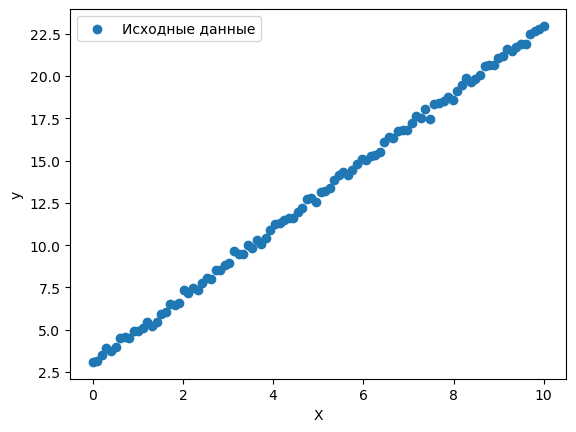

In [92]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Генерация синтетических данных
np.random.seed(42)
X = np.linspace(0, 10, 100)  # 100 точек от 0 до 10
y = 2 * X + 3 + 0.2*np.random.normal(0, 1, 100)  # y = 2x + 3 + шум

# Визуализация данных
plt.scatter(X, y, label='Исходные данные')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

In [94]:
# Создание модели
model = Sequential([
    Dense(units=1, input_shape=[1])  # Один полносвязный слой (Dense) с 1 нейроном
])

# Компиляция модели
model.compile(
    optimizer='adam',  # Оптимизатор (можно также использовать 'sgd')
    loss='mse',       # Функция потерь (среднеквадратичная ошибка)
    metrics=['mae']   # Метрика (средняя абсолютная ошибка)
)

# Вывод структуры модели
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 1)                   │               2 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 248.8302 - mae: 14.2740 
Epoch 2/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 256.6329 - mae: 14.5719
Epoch 3/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 229.8880 - mae: 13.6231
Epoch 4/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 246.8261 - mae: 14.3220
Epoch 5/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 242.1725 - mae: 14.0370
Epoch 6/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 245.7476 - mae: 14.1709
Epoch 7/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 245.2232 - mae: 14.2148
Epoch 8/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 241.8233 - mae: 14.0936
Epoch 9/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 245.4887 - mae: 14.1469
Epoch 10/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 233.6137 - mae: 13.8239
Epoch 11/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 258.2770 - mae: 14.6195
Epoch 12/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 241.4187 - mae: 14.1140


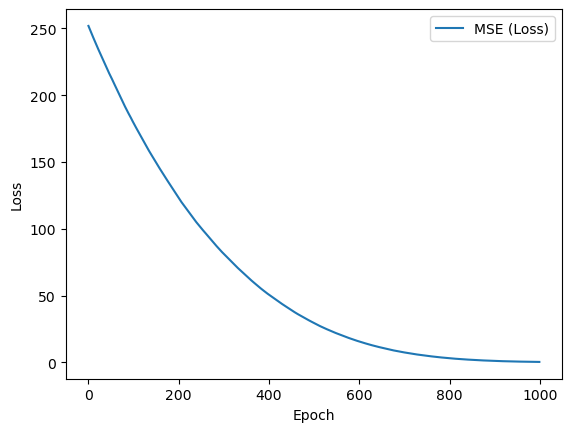

In [96]:
# Обучение модели
history = model.fit(
    X, y,
    epochs=1000,       # Количество эпох
    verbose=1         # Вывод процесса обучения
)

# График изменения ошибки
plt.plot(history.history['loss'], label='MSE (Loss)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


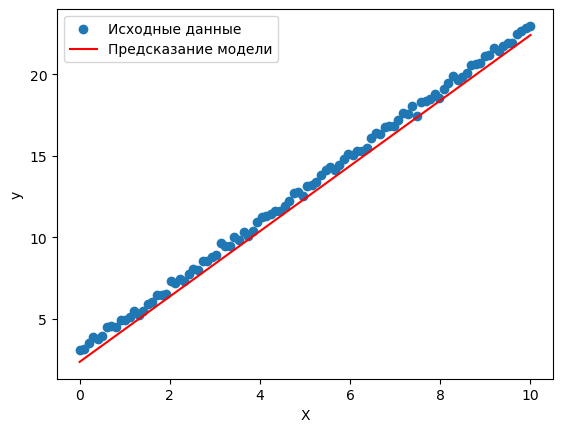

Обученные коэффициенты: w = 2.00, b = 2.38


In [98]:
# Предсказание на новых данных
X_test = np.linspace(0, 10, 50)
y_pred = model.predict(X_test)

# Визуализация
plt.scatter(X, y, label='Исходные данные')
plt.plot(X_test, y_pred, color='red', label='Предсказание модели')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

# Вывод обученных коэффициентов
w, b = model.layers[0].get_weights()
print(f"Обученные коэффициенты: w = {w[0][0]:.2f}, b = {b[0]:.2f}")